# Exploratory Data Analysis: Traffic Accidents in Madrid (2016-2024)
This notebook performs an EDA on the consolidated dataset of traffic accidents and traffic sensor data in Madrid.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plots style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Initial Inspection

In [4]:
df = pd.read_csv('accidentes_con_trafico_final.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311199 entries, 0 to 311198
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   fecha                 311199 non-null  datetime64[ns]
 1   hora                  311199 non-null  object        
 2   dia_semana            311199 non-null  object        
 3   distrito              311192 non-null  object        
 4   num_expediente        311199 non-null  object        
 5   tipo_accidente        311193 non-null  object        
 6   tipo_vehiculo         309737 non-null  object        
 7   sexo                  311199 non-null  object        
 8   rango_edad            311199 non-null  object        
 9   estado_meteorológico  285118 non-null  object        
 10  coordenada_x_utm      311199 non-null  float64       
 11  coordenada_y_utm      311199 non-null  float64       
 12  direccion_unica       311199 non-null  object        
 13 

,fecha,hora,dia_semana,distrito,num_expediente,tipo_accidente,tipo_vehiculo,sexo,rango_edad,estado_meteorológico,coordenada_x_utm,coordenada_y_utm,direccion_unica,es_festivo,id_sensor_cercano,intensidad,ocupacion,vmed
0,2016-01-01,0:00:00,viernes,puente de vallecas,2016/4,atropello,turismo,hombre,de 30 a 34 anos,despejado,442270.3905,4446288.618,AVENIDA DE PABLO NERUDA - CALLE DEL GOLFO DE D...,1,5385,510.0,1.00,0.0
1,2016-01-01,1:00:00,viernes,ciudad lineal,2016/437,colisión doble,turismo,mujer,de 30 a 34 anos,despejado,444388.1000,4474950.270,AVENIDA DEL MARQUES DE CORBERA NUM 7,1,10302,NaN,NaN,NaN
2,2016-01-01,1:00:00,viernes,ciudad lineal,2016/437,colisión doble,motocicleta,hombre,de 25 a 29 años,despejado,444388.1000,4474950.270,AVENIDA DEL MARQUES DE CORBERA NUM 7,1,10302,NaN,NaN,NaN
3,2016-01-01,2:00:00,viernes,chamartin,2016/31,colisión múltiple,turismo,mujer,de 50 a 54 años,despejado,439733.2051,4451776.428,AUTOVIA M-30 CALZADA 1 KM. 1300,1,5385,825.0,1.75,0.0
4,2016-01-01,2:00:00,viernes,chamartin,2016/31,colisión múltiple,turismo,mujer,de 50 a 54 años,despejado,439733.2051,4451776.428,AUTOVIA M-30 CALZADA 1 KM. 1300,1,5385,825.0,1.75,0.0


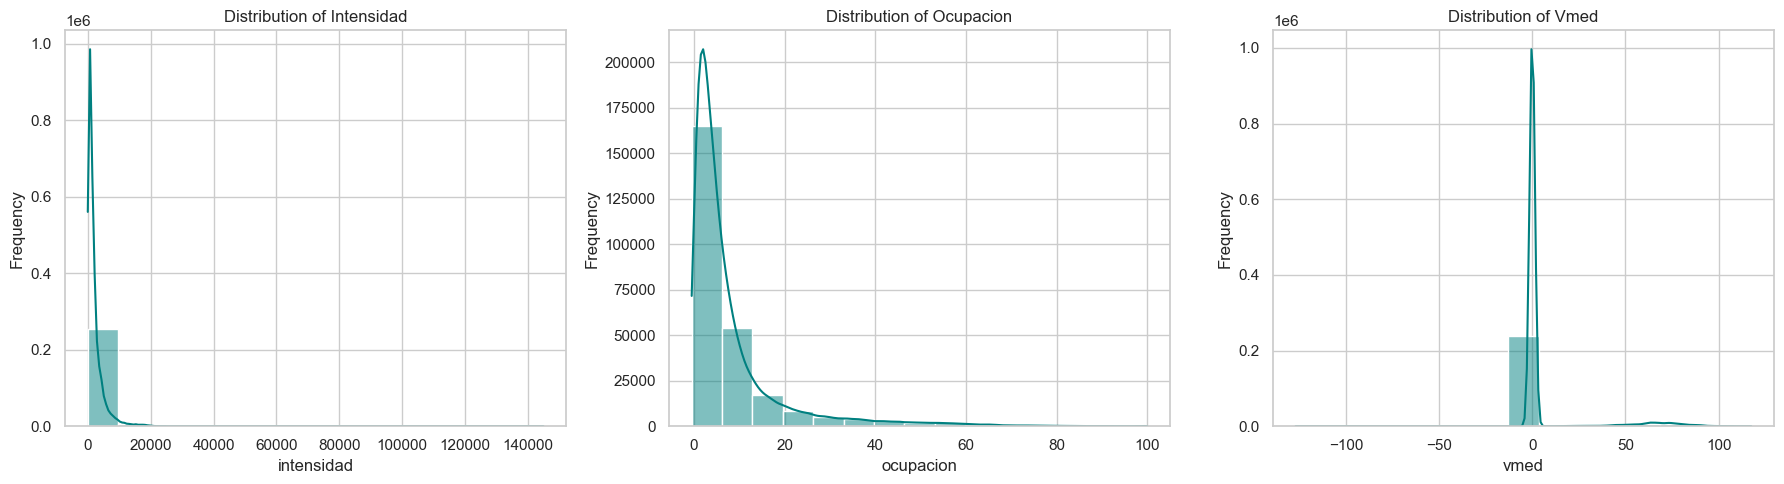

In [47]:
cols_traffic = ['intensidad', 'ocupacion', 'vmed']

plt.figure(figsize=(18, 5))
for i, col in enumerate(cols_traffic):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col].dropna(), bins=15, kde=True, color='teal')
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## 2. Temporal Analysis
We analyse how accidents are distributed across hours, days of the week, and holiday status.

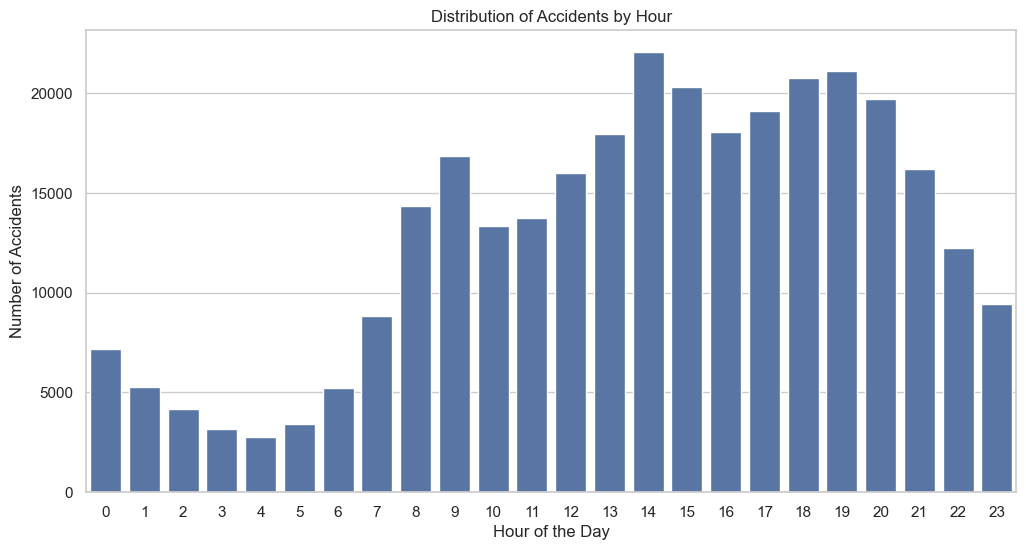

In [31]:
# Accidents by Hour and Holiday status
df['hora_dt'] = pd.to_datetime(df['hora'], format='%H:%M:%S').dt.hour
sns.countplot(data=df, x='hora_dt')
plt.title('Distribution of Accidents by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Accidents')
plt.show()

We can see that the number of accidents starts to increase when people start going to work (from 6am to 9am), then increase again with the lunch hours (1pm to 3pm) and again when people leave work (6pm to 9pm). There are less accidents at night.

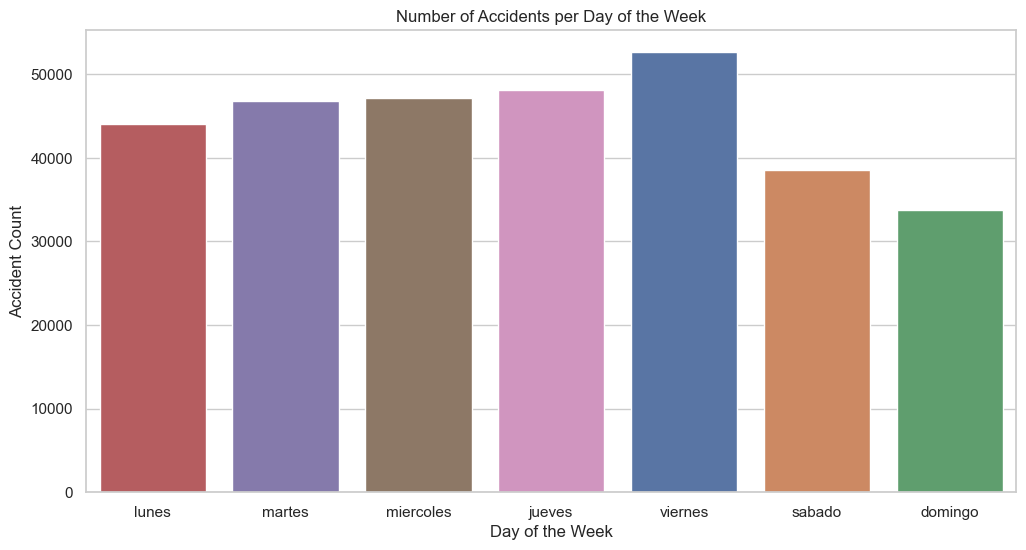

In [11]:
# Accidents by Day of the Week
order = ['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo']
sns.countplot(data=df, x='dia_semana', order=order, hue='dia_semana', legend=False)
plt.title('Number of Accidents per Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Accident Count')
plt.show()

The most amount of accidents occurred on a Friday. The amount of accidents drops drastically on a weekend.

Holidays have an accident rate of 72.24% compared to labour days.


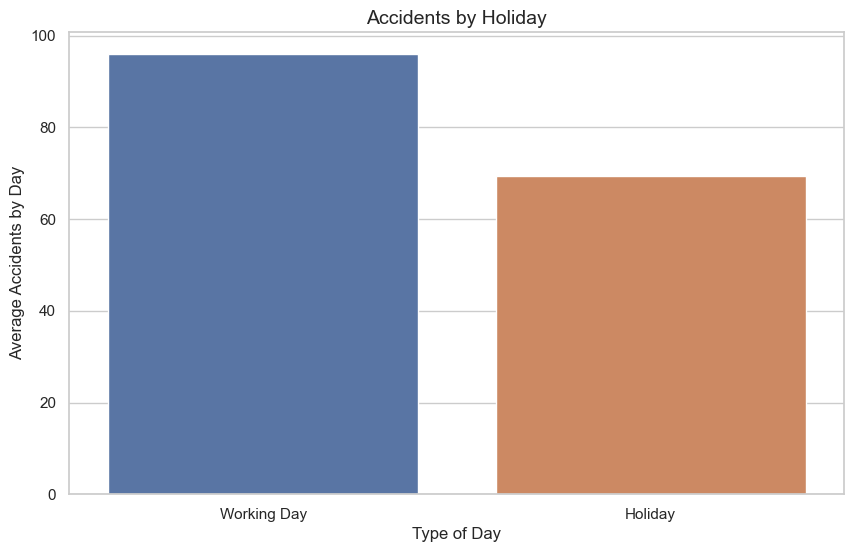

In [88]:
accidentes_by_holiday = df.groupby(['fecha', 'es_festivo']).size().reset_index(name='num_acc')
comparison = accidentes_by_holiday.groupby('es_festivo')['num_acc'].mean().reset_index()
comparison.columns = ['Is Holiday', 'Mean Accidents/Day']
comparison['Type of Day'] = comparison['Is Holiday'].map({0: 'Working Day', 1: 'Holiday'})

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison, x='Type of Day', y='Mean Accidents/Day', hue='Type of Day', legend=False)
plt.title('Accidents by Holiday', fontsize=14)
plt.ylabel('Average Accidents by Day')

mean_lab = comparison.loc[comparison['Is Holiday'] == 0, 'Mean Accidents/Day'].values[0]
mean_hol = comparison.loc[comparison['Is Holiday'] == 1, 'Mean Accidents/Day'].values[0]
print(f"Holidays have an accident rate of {round((mean_hol/mean_lab)*100, 2)}% compared to labour days.")

## 3. Spatial Analysis
Analyzing which districts have the highest frequency of accidents.

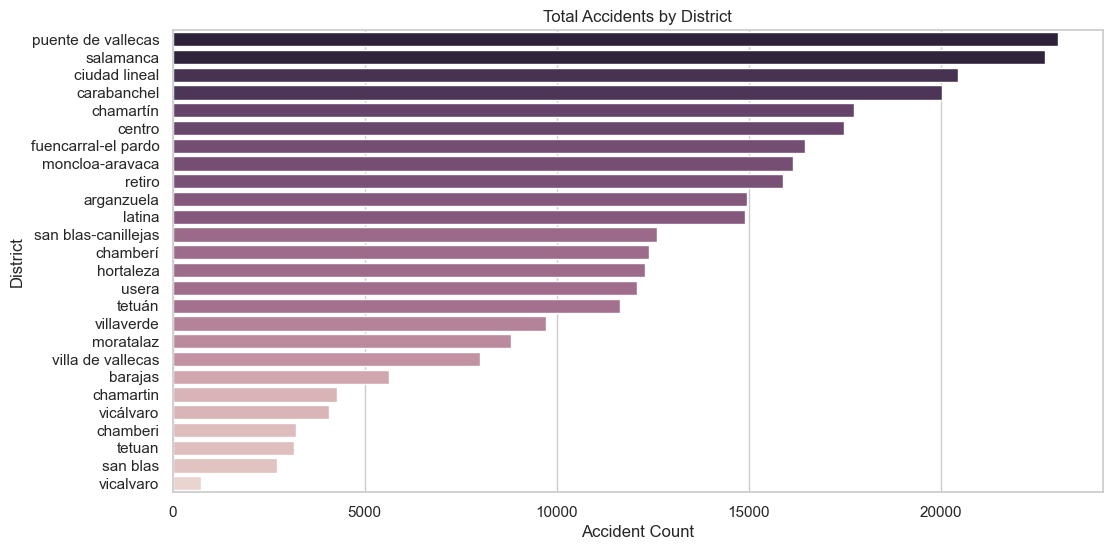

In [15]:
distrito_counts = df['distrito'].value_counts().reset_index()
sns.barplot(data=distrito_counts, x='count', y='distrito', hue='count', legend=False)
plt.title('Total Accidents by District')
plt.xlabel('Accident Count')
plt.ylabel('District')
plt.show()

Puente de Vallecas is surrounded by many large avenues and highways, which is an entrance and exit to the city, so it makes sense to have a lot of accidents in this district. Salamanca is a large downtown area of Madrid with many things to do. Ciudad Lineal is a suburban area with a lot of housing. We can see the diverse range of types of districts does not influence the amount of accidents in them.

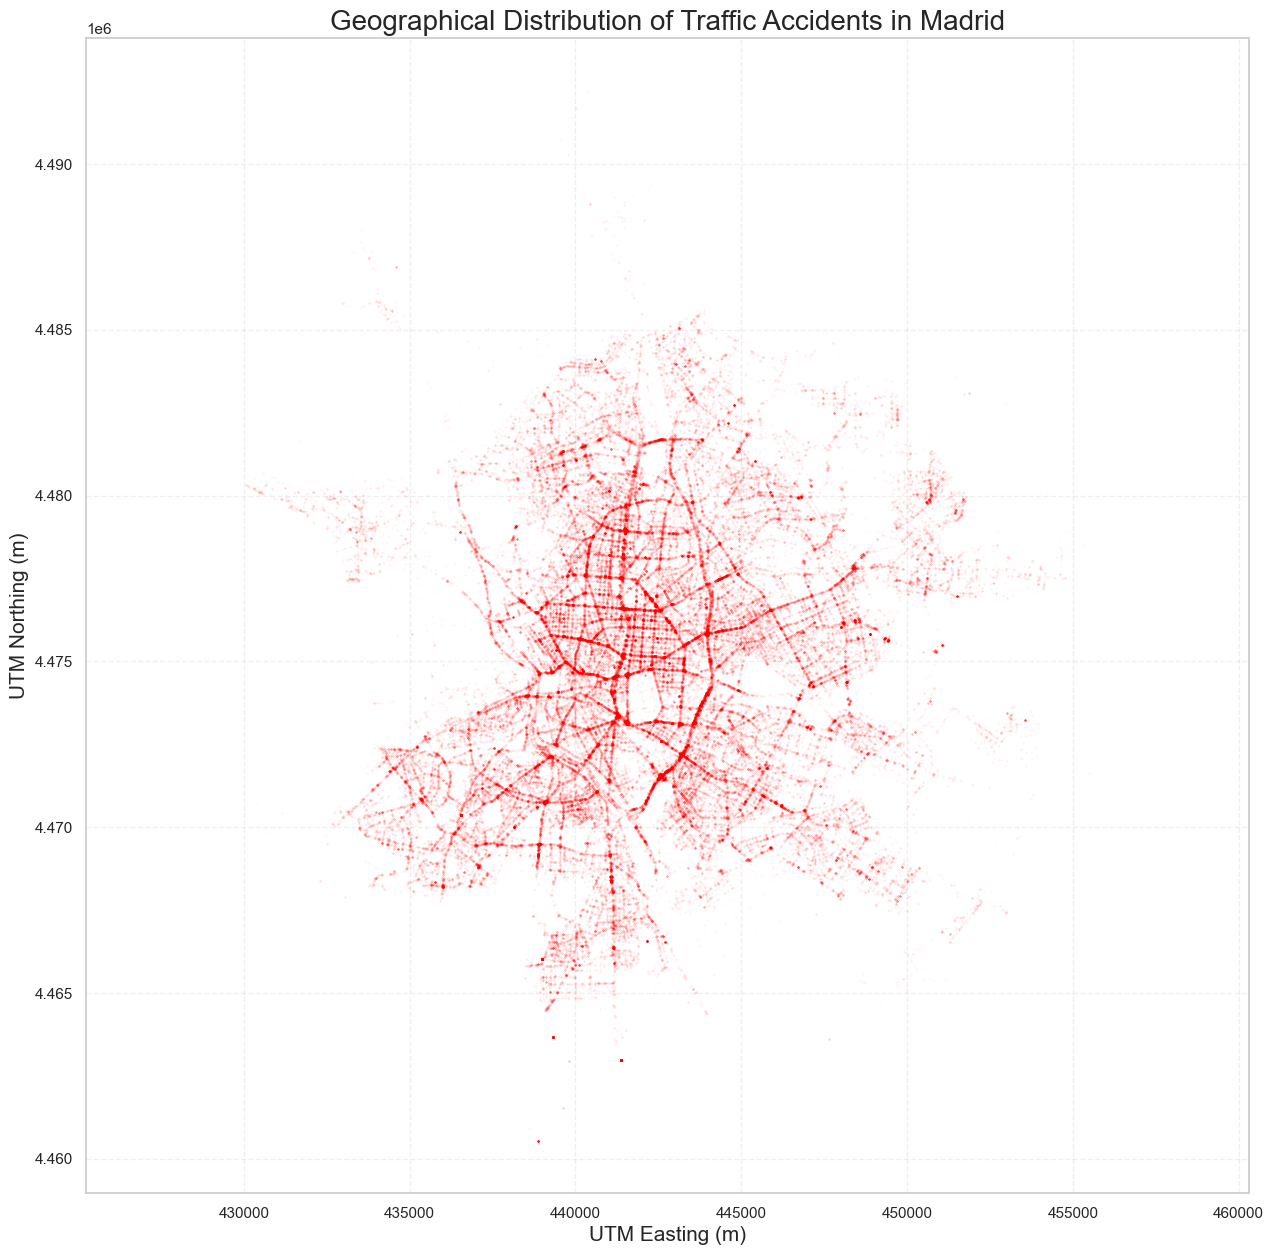

In [102]:
# Filter for valid UTM coordinates in Madrid area
# Madrid UTM Zone 30N coordinates are roughly:
# X (Easting): 430,000 - 455,000
# Y (Northing): 4,460,000 - 4,495,000
mask = (df['coordenada_x_utm'] > 430000) & (df['coordenada_x_utm'] < 460000) & \
       (df['coordenada_y_utm'] > 4460000) & (df['coordenada_y_utm'] < 4495000)
df_map = df[mask].copy()


plt.figure(figsize=(15, 15))
plt.scatter(df_map['coordenada_x_utm'], 
            df_map['coordenada_y_utm'], 
            c='red', 
            s=0.1, 
            alpha=0.05, 
            label='Accident Location')

plt.title('Geographical Distribution of Traffic Accidents in Madrid', fontsize=20)
plt.xlabel('UTM Easting (m)', fontsize=15)
plt.ylabel('UTM Northing (m)', fontsize=15)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.3)

## 4. Accident and Vehicle Types
Common causes and vehicles involved.

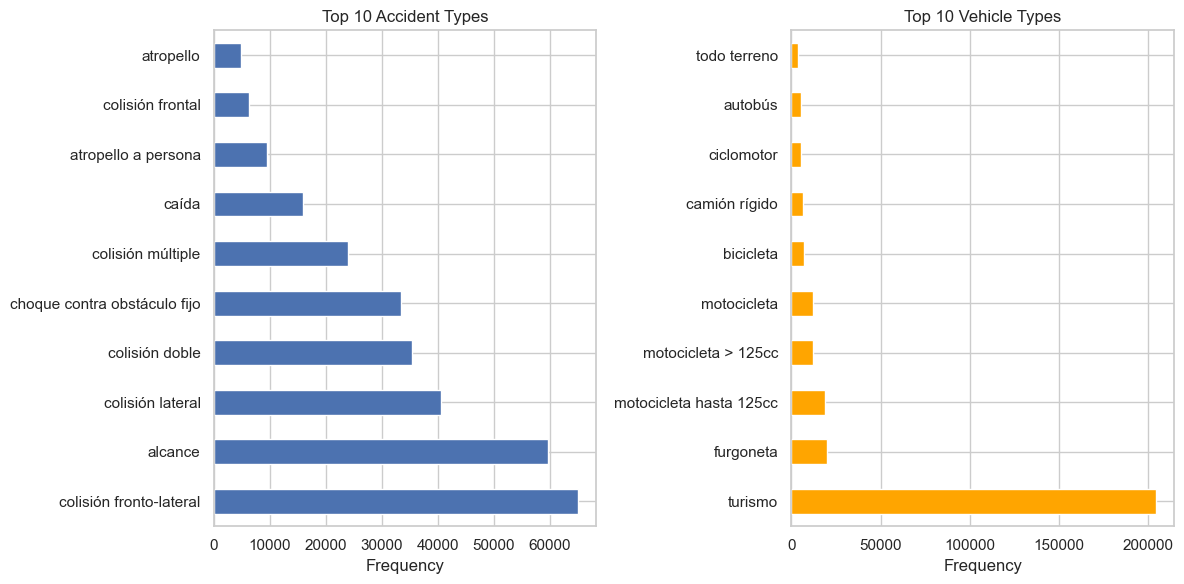

In [39]:
plt.subplot(1, 2, 1)
df['tipo_accidente'].value_counts().head(10).plot(kind='barh', title='Top 10 Accident Types', xlabel='Frequency', ylabel='')
plt.subplot(1, 2, 2)
df['tipo_vehiculo'].value_counts().head(10).plot(kind='barh', color='orange', title='Top 10 Vehicle Types', xlabel='Frequency', ylabel='')
plt.tight_layout()
plt.show()

Frontolateral and rearend accidents are the most common types. The majority of accidents involve normal cars, with vans being the second most involved in collisions.

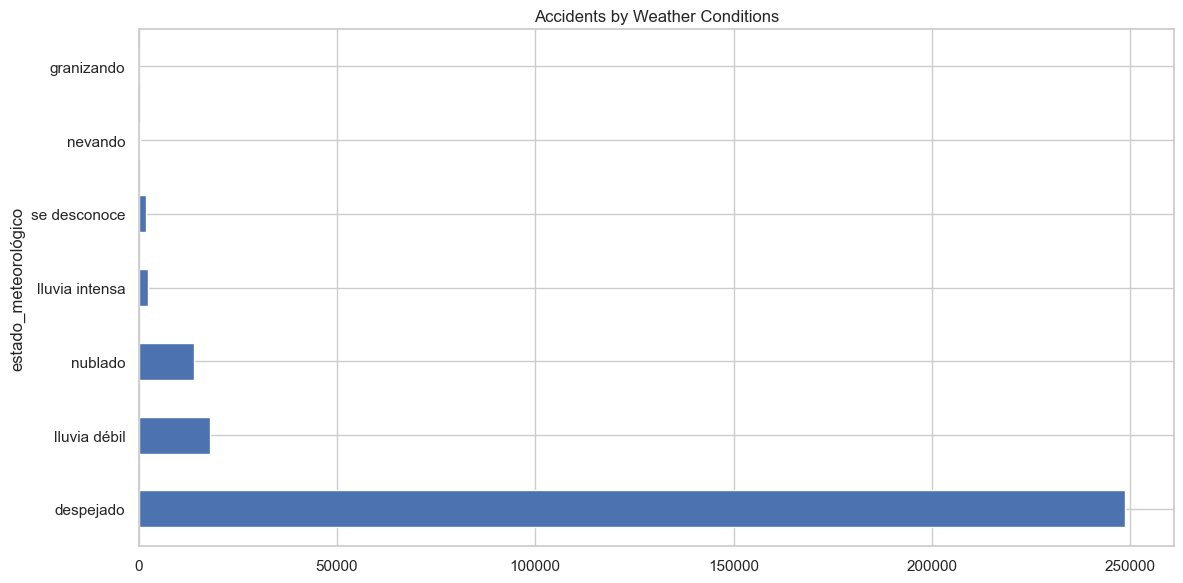

In [33]:
df['estado_meteorológico'].value_counts().plot(kind='barh', title='Accidents by Weather Conditions')
plt.tight_layout()
plt.show()

The majority of accidents occurred under clear conditions, followed by rain and cloudy weather. Very few accidents happened in snowy or icy conditions.

## 5. Traffic Influence
Analyzing the relationship between traffic intensity, speed, and accident occurrence.

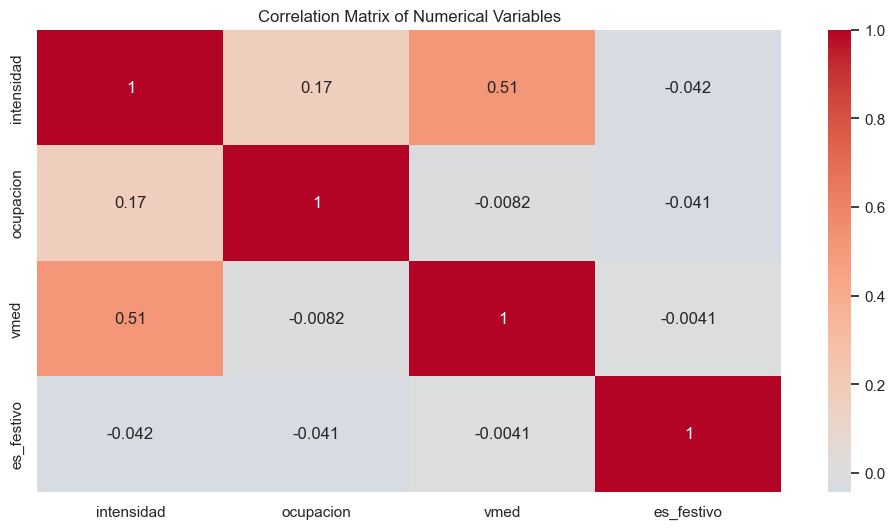

In [80]:
# Correlation Heatmap between numerical variables
corr = df[['intensidad', 'ocupacion', 'vmed', 'es_festivo']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

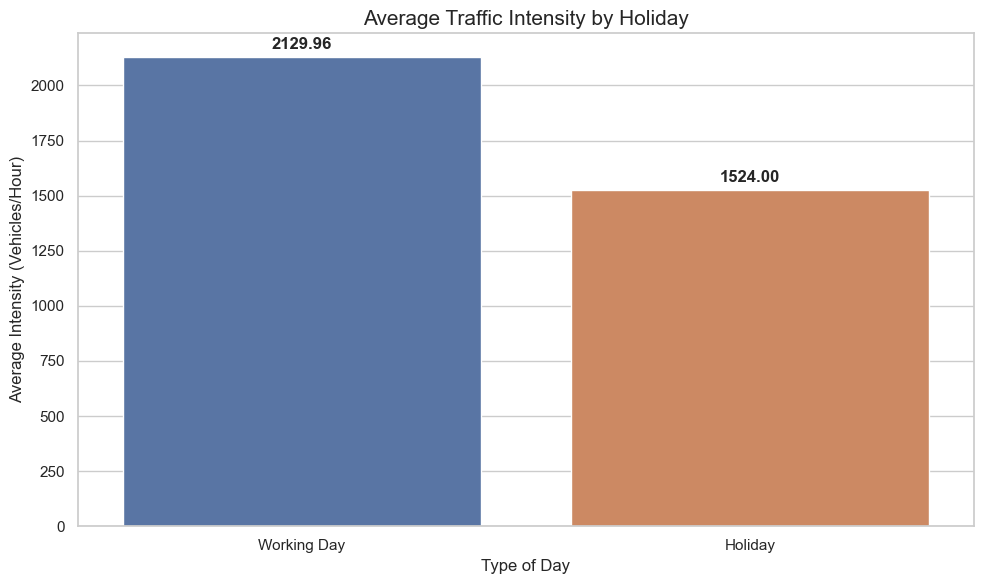

In [92]:
df['Type of Day'] = df['es_festivo'].map({0: 'Working Day', 1: 'Holiday'})
mean_intensity = df.groupby('Type of Day')['intensidad'].mean().reset_index()
mean_intensity = mean_intensity.sort_values('Type of Day', ascending=False)

plt.figure(figsize=(10, 6))
barplot = sns.barplot(data=mean_intensity, x='Type of Day', y='intensidad', hue='Type of Day', legend=False)
plt.title('Average Traffic Intensity by Holiday', fontsize=15)
plt.ylabel('Average Intensity (Vehicles/Hour)', fontsize=12)
plt.xlabel('Type of Day', fontsize=12)
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=12, fontweight='bold')

plt.tight_layout()